# Импорт

In [48]:
!apt-get install -qq -y quantum-espresso
!pip install -q ase

In [49]:
!pip show ase | grep Version

Version: 3.28.0


In [50]:
import os
import tarfile

import ase.io
from ase import Atoms

import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
from ase.visualize import view

from ase.calculators.espresso import Espresso, EspressoProfile

# Структуры

## CIF
> Примитивная кубическая ячейка γ′-фазы Ni₃Al (структурный тип Cu₃Au, L1₂). Пространственная группа **Pm 3 m** (№ 221). Параметр решётки **a = 3.52305 Å**, объём ячейки **43.73 Å³**. Атом алюминия занимает позицию **1a** (0, 0, 0); три атома никеля располагаются в позициях **3c** с координатами (0, ½, ½), (½, 0, ½) и (½, ½, 0). Число формульных единиц Z = 1 (всего 4 атома на ячейку: 1 Al + 3 Ni).

Источник: https://next-gen.materialsproject.org/materials/mp-2593/

In [51]:
ni3al = ase.io.read("./CIF_Ni3Al/AlNi3.cif")
view(ni3al, viewer='x3d')

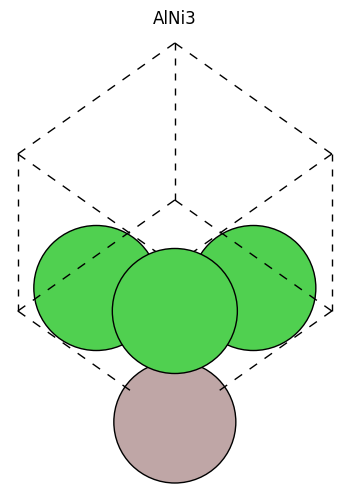

In [52]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_atoms(ni3al, ax, radii=0.8, rotation=('45x,45y,90z'))
ax.set_title(ni3al.get_chemical_formula())
ax.set_axis_off()

plt.show()

In [53]:
a_Ni = 3.47
ni_fcc = Atoms("Ni4", positions=[(0,0,0), (0.5,0.5,0), (0.5,0,0.5), (0,0.5,0.5)],
               cell=[[a_Ni,0,0], [0,a_Ni,0], [0,0,a_Ni]])

a_Al = 3.97
al_fcc = Atoms("Al4", positions=[(0,0,0), (0.5,0.5,0), (0.5,0,0.5), (0,0.5,0.5)],
               cell=[[a_Al,0,0], [0,a_Al,0], [0,0,a_Al]])

> Параметры решетки для Ni и Al, взятые из PseudoDojo (3.47 Å и 3.97 Å), отличаются от экспериментальных значений (3.52 Å и 4.05 Å). Это связано с типом псевдопотенциала. Норм-консервирующие (NC) псевдопотенциалы, такие как ONCVPSP, часто дают параметры решетки немного меньше экспериментальных, в отличие от ультрамягких (US), которые обычно их завышают.

1. Отчет для Ni: https://www.pseudo-dojo.org/pseudos/nc-sr-04_pw_standard/Ni.html
2. Отчет для Al: https://www.pseudo-dojo.org/pseudos/nc-sr-04_pw_standard/Al.html

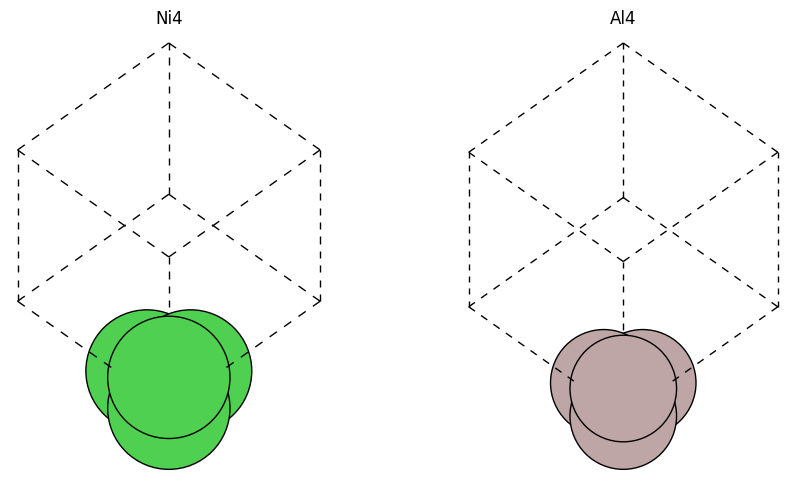

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

plot_atoms(ni_fcc, ax1, radii=0.8, rotation=('45x,45y,90z'))
ax1.set_title(ni_fcc.get_chemical_formula())
ax1.set_axis_off()

plot_atoms(al_fcc, ax2, radii=0.8, rotation=('45x,45y,90z'))
ax2.set_title(al_fcc.get_chemical_formula())
ax2.set_axis_off()

plt.tight_layout()
plt.show()

## Псевдопотенциалы

* UPF version=`2.0.1`

> Оба потенциала сгенерированы программой ONCVPSP v3.3.0 (D. R. Hamann) в полностью релятивистском режиме. Они являются норм-сохраняющими (NC) и включают нелинейную коррекцию остовного заряда (NLCC). В качестве обменно-корреляционного функционала использован PBE.

Источник: https://www.pseudo-dojo.org/
1. Type: NC FR (ONCVPSP v0.4)
2. XC: PBE
3. Accuracy: standart
4. Format: UPF.


In [55]:
pseudo_dir = "./pseudo_Ni3Al"
pseudopotentials = {'Ni': 'Ni.upf', 'Al': 'Al.upf'}

# Параметры расчёта

In [56]:
ecutwfc = 60
ecutrho = 480
degauss = 0.015
conv_thr = 1e-6

input_data = {
    'system': {
        'ecutwfc': ecutwfc,
        'ecutrho': ecutrho,
        'occupations': 'smearing',
        'smearing': 'methfessel-paxton',
        'degauss': degauss,
        'input_dft': 'pbe',
    },
    'electrons': {
        'conv_thr': conv_thr,
        'mixing_mode': 'local-TF',
        'mixing_beta': 0.7,
        'mixing_ndim': 8,
        'diagonalization': 'david',
        'diago_david_ndim': 6,
    }
}

# Функция расчёта

In [57]:
def calc_energy(structure, prefix, kpts):

    outdir = f"./tmp_{prefix}"
    os.makedirs(outdir, exist_ok=True)

    calc = Espresso(
        profile=EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir),
        # cmdline=['-npool', '4'],
        prefix=prefix,
        pseudopotentials=pseudopotentials,
        kpts=kpts,
        input_data=input_data,
        outdir=outdir
    )

    structure.calc = calc
    return structure.get_potential_energy()

# Расчёт энергий

Если за эталон взять расчёт чистого Ni (a=3.47 Å, сетка **8×8×8**), то эквивалентная плотность k‑точек требует пропорционального увеличения числа точек с ростом параметра ячейки:

$ \mathrm{Ni}: a = 3.47 \text{ Å} \rightarrow N = 8 $

$ \mathrm{Al}: a = 3.97 \text{ Å} \rightarrow N = 8 \times \dfrac{3.97}{3.47} \approx 9.15 \rightarrow \mathbf{9\times9\times9} $

$ \mathrm{Ni_3Al}: a = 3.523 \text{ Å} \rightarrow N = 8 \times \dfrac{3.523}{3.47} \approx 8.12 \rightarrow \mathbf{8\times8\times8} $

In [58]:
kpts_Ni3Al = (8, 8, 8)
kpts_Ni = (8, 8, 8)
kpts_Al = (9, 9, 9)

In [59]:
E_Ni3Al = calc_energy(ni3al, "Ni3Al", kpts_Ni3Al)
E_Ni    = calc_energy(ni_fcc, "Ni", kpts_Ni)
E_Al    = calc_energy(al_fcc, "Al", kpts_Al)

In [60]:
print(f"E(Ni3Al) = {E_Ni3Al:.6f}")
print(f"E(Ni)    = {E_Ni:.6f}")
print(f"E(Al)    = {E_Al:.6f}")

E(Ni3Al) = -13744.960851
E(Ni)    = -15779.724203
E(Al)    = 227.367931


# Архивация расчетов

In [61]:
folders = ['tmp_Ni3Al', 'tmp_Ni', 'tmp_Al']

for folder in folders:
    if os.path.isdir(folder):
        archive_name = f"{folder}.tar.gz"
        with tarfile.open(archive_name, "w:gz") as tar:
            tar.add(folder, arcname=os.path.basename(folder))